# Session 1 — Foundations and Research Design of Event Studies

**Course: Event Studies in Finance & Economics**

*Mathis Mourey*

---

Here, we develop the foundations of event studies from the ground up. 

We begin with the question that motivates the entire methodology: **how can we measure the economic impact of a discrete event on asset prices?** We then formalize the key concepts, notation, and assumptions, before applying them to real data.

The structure is as follows: We first discuss why event studies exist and what they can (and cannot) identify. We then introduce the timeline that governs every event study, define abnormal returns formally, show how individual abnormal returns aggregate into test statistics, and close with a hands-on application to an earnings announcement.

**References for this session:**

- Ball, R. and Brown, P. (1968). An Empirical Evaluation of Accounting Income Numbers. *Journal of Accounting Research*, 6(2), 159–178.
- Fama, E.F. (1970). Efficient Capital Markets: A Review of Theory and Empirical Work. *Journal of Finance*, 25(2), 383–417.
- Fama, E.F., Fisher, L., Jensen, M.C. and Roll, R. (1969). The Adjustment of Stock Prices to New Information. *International Economic Review*, 10(1), 1–21.
- MacKinlay, A.C. (1997). Event Studies in Economics and Finance. *Journal of Economic Literature*, 35(1), 13–39.
- Campbell, J.Y., Lo, A.W. and MacKinlay, A.C. (1997). *The Econometrics of Financial Markets*. Princeton University Press. Chapter 4.
- Binder, J.J. (1998). The Event Study Methodology Since 1969. *Review of Quantitative Finance and Accounting*, 11(2), 111–137.

## 1. Why Event Studies?

The central question of empirical finance is deceptively simple: does a particular event affect the value of a firm? A merger announcement, a regulatory change, an earnings surprise, a central bank decision; each of these constitutes an arrival of new information into the market. If markets process information efficiently, prices should adjust to reflect this new information, and the adjustment should be observable.

Event studies exploit exactly this logic. The methodology owes to Fama, Fisher, Jensen, and Roll (1969), who examined how stock prices adjust to stock split announcements. Their paper established the template that thousands of subsequent studies follow: isolate the event, estimate what the return *would have been* absent the event, and attribute the difference to the event itself.

The approach rests on three premises:

1. **Information arrives discretely.** The event has a well-defined date (or narrow window) at which the market first learns of it.
2. **Markets are sufficiently efficient.** Prices incorporate the new information rapidly enough that the price impact is concentrated around the event date.
3. **A counterfactual is estimable.** We can construct a reasonable estimate of what the return would have been had the event not occurred.

When all three hold, the event study provides a clean test of economic hypotheses. When they fail, as they sometimes do, the methodology requires some adjustments, which later sessions will address.

It is worth noting what event studies *cannot* do. They measure the market's *perceived* impact of an event on firm value. They do not, by themselves, establish causality in a structural sense. If event timing is endogenous (the firm chose when to announce), the abnormal return reflects both the event's content and the market's interpretation of the firm's timing decision. We return to this identification problem in Session 6 (cross-sectional regression) and Session 8 (difference-in-differences).

## 2. The Efficient Market Hypothesis as Theoretical Backbone

The event study methodology is logically intertwined with the Efficient Market Hypothesis (EMH). Fama (1970) defined an efficient market as one in which "prices always fully reflect available information." In such a market, any new information is incorporated into prices immediately, leaving no systematic profit opportunities.

Fama distinguished three forms of market efficiency:

- **Weak form**: prices reflect all past trading information (prices, volumes). Technical analysis should not generate abnormal returns.
- **Semi-strong form**: prices reflect all publicly available information (financial statements, news, macroeconomic data). Fundamental analysis of public data should not generate abnormal returns.
- **Strong form**: prices reflect all information, including private (insider) information. Even insiders should not systematically earn abnormal returns.

Event studies are the primary empirical tool for testing semi-strong efficiency. The logic runs in both directions. If we *assume* semi-strong efficiency, then any abnormal return around an event reflects the market's unbiased assessment of the event's value impact. Conversely, if we observe that prices adjust *before* the public announcement, this constitutes evidence against semi-strong efficiency (or evidence that the information leaked).

This dual role means that every event study embeds a **joint hypothesis problem** (Fama, 1970). We test the null that the event has no impact, but under the maintained hypothesis that our model of normal returns is correct *and* that markets are efficient. A rejection could mean the event matters, or that our benchmark model is wrong, or that markets are inefficient. This problem cannot be fully resolved, but it can be mitigated by using better benchmark models (Session 2) and robust test statistics (Sessions 4–5).

For the remainder of this session, we adopt the semi-strong form as a working assumption. Prices adjust to public information quickly, so the abnormal return in a narrow window around the event date provides a valid measure of the event's economic impact.

## 3. The Event Study Timeline

Every event study partitions the calendar around a focal date. The notation below follows MacKinlay (1997) and Campbell, Lo, and MacKinlay (1997, Ch. 4).

Let $\tau = 0$ denote the **event date**, that is to say the trading day on which the event becomes public knowledge. All other dates are measured relative to $\tau = 0$.

The timeline is divided into three (sometimes four) windows:

**Estimation window** $[\tau_0, \tau_1]$: A period *before* the event, typically 120 to 250 trading days, used to estimate the parameters of the normal return model. The estimation window should not overlap with the event window, to avoid contaminating the parameter estimates with the event's effect.

**Event window** $[\tau_1 + 1, \tau_2]$: The short period around the event date during which we measure the price impact. A common choice is $[-1, +1]$ (the day before, the day of, and the day after the event), which captures pre-announcement leakage and post-announcement drift. Narrower windows (e.g., $[0, 0]$) have more statistical power but risk missing part of the price adjustment.

**Post-event window** $[\tau_2 + 1, \tau_3]$: An optional period after the event window, used to study whether the initial price reaction is permanent or reverses. Post-event drift is one of the most robust anomalies in finance (Bernard and Thomas, 1989).

The gap between the estimation window and the event window is a **buffer** (sometimes called a guard period). Its purpose is to prevent any pre-event information leakage from biasing the estimation of normal returns. A buffer of 5 to 10 trading days is typical.

The figure below illustrates this structure.

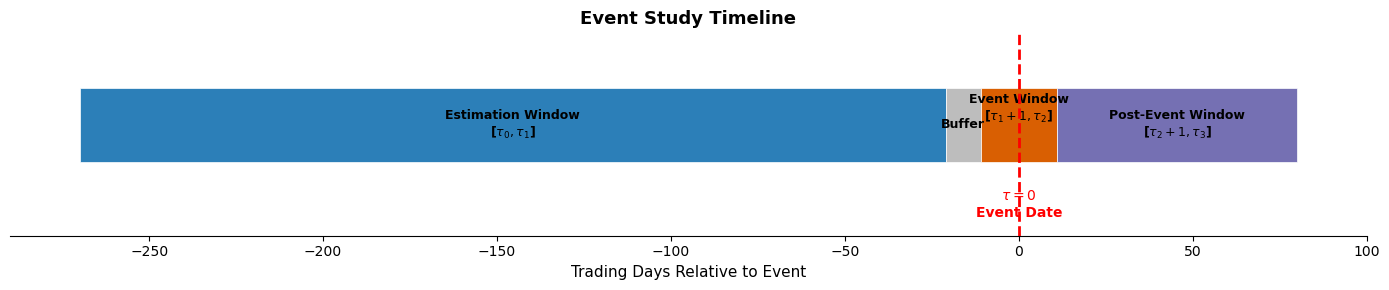

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 3))

# Timeline segments: (start, end, color, label)
segments = [
    (-270, -21, '#2c7fb8', 'Estimation Window\n[$\\tau_0, \\tau_1$]'),
    (-21, -11, '#bdbdbd', 'Buffer'),
    (-11, 11, '#d95f02', 'Event Window\n[$\\tau_1+1, \\tau_2$]'),
    (11, 80, '#7570b3', 'Post-Event Window\n[$\\tau_2+1, \\tau_3$]'),
]

for start, end, color, label in segments:
    if label=="Event Window\n[$\\tau_1+1, \\tau_2$]":
        ax.barh(0, end - start, left=start, height=0.4, color=color, edgecolor='white', linewidth=0.5)
        ax.text((start + end) / 2, 0, label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        ax.barh(0, end - start, left=start, height=0.4, color=color, edgecolor='white', linewidth=0.5)
        ax.text((start + end) / 2, 0, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Event date marker
ax.axvline(0, color='red', linewidth=2, linestyle='--', zorder=5)
ax.text(0, -0.35, '$\\tau = 0$\nEvent Date', ha='center', va='top', fontsize=10, color='red', fontweight='bold')

ax.set_xlim(-290, 100)
ax.set_ylim(-0.6, 0.5)
ax.set_xlabel('Trading Days Relative to Event', fontsize=11)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_title('Event Study Timeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Design Choices and Their Consequences

Each window length is a choice with statistical consequences.

**Estimation window length.** Longer estimation windows yield more precise parameter estimates for the normal return model, but they increase the risk of structural breaks (a change in the firm's risk profile that occurred during the window). MacKinlay (1997) recommends 120 trading days as a minimum; 250 days (one calendar year) is common in practice. If the firm experienced a major event during the estimation window (e.g., a prior merger), the researcher should either extend the window further back or exclude that sub-period.

**Event window length.** Shorter event windows have higher statistical power because they contain less noise from non-event return variation. However, too narrow a window risks missing the full price adjustment. For well-defined events (earnings announcements with known dates), $[-1, +1]$ is standard. For events where the exact date of information arrival is uncertain (regulatory changes, policy rumors), wider windows such as $[-5, +5]$ or even $[-10, +10]$ may be necessary.

**Buffer length.** The buffer prevents "leakage" of the event's effect into the estimation window. If the event was partially anticipated (e.g., a widely expected merger), a longer buffer is advisable. Peterson (1989) and Binder (1998) discuss this in detail.

A general principle: the researcher should justify each choice *before* looking at the results. Post-hoc window selection introduces a severe form of specification searching.

## 4. Defining Abnormal Returns

The abnormal return is the difference between the realized return and the return that would have been expected absent the event. Let $R_{i,\tau}$ denote the return on security $i$ on event-time day $\tau$, and let $E[R_{i,\tau} \mid \mathcal{F}_{\tau-1}]$ denote the expected (normal) return conditional on the information set $\mathcal{F}_{\tau-1}$ available at the end of day $\tau - 1$. The abnormal return is:

$$
AR_{i,\tau} = R_{i,\tau} - E[R_{i,\tau} \mid \mathcal{F}_{\tau-1}]
$$

In practice, the conditional expectation is replaced by a model-based estimate $\hat{R}_{i,\tau}$. The simplest models are:

**Constant mean return model.** The expected return is the sample mean of the firm's returns over the estimation window:

$$
\hat{R}_{i,\tau} = \hat{\mu}_i = \frac{1}{L} \sum_{t=\tau_0}^{\tau_1} R_{i,t}
$$

where $L = \tau_1 - \tau_0 + 1$ is the length of the estimation window. This model is surprisingly robust for short event windows (Brown and Warner, 1980, 1985).

**Market model.** The expected return is a linear function of the market return:

$$
R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}, \qquad \varepsilon_{i,t} \sim \mathcal{N}(0, \sigma^2_{\varepsilon_i})
$$

Parameters $\hat{\alpha}_i$ and $\hat{\beta}_i$ are estimated by OLS over the estimation window. The abnormal return is then:

$$
AR_{i,\tau} = R_{i,\tau} - \hat{\alpha}_i - \hat{\beta}_i R_{m,\tau}
$$

The market model accounts for the portion of the firm's return driven by market-wide movements, thereby reducing the variance of the abnormal return and increasing the power of the test. Session 2 will extend this to multi-factor models (Fama-French, Carhart).

Under the null hypothesis that the event has no impact, $AR_{i,\tau}$ has mean zero and variance:

$$
\text{Var}(AR_{i,\tau}) = \sigma^2_{\varepsilon_i} + \frac{1}{L}\left[1 + \frac{(R_{m,\tau} - \hat{\mu}_m)^2}{\hat{\sigma}^2_m}\right]
$$

The second term reflects estimation error in $\hat{\alpha}_i$ and $\hat{\beta}_i$; it is negligible when the estimation window is long (say, $L > 100$), which is why most studies use long estimation windows.

## 5. Aggregation: From AR to CAR to CAAR

A single abnormal return on a single day is rarely of interest by itself. The event's full impact may unfold over several days, and we typically study multiple firms or multiple events. The aggregation proceeds in two dimensions: across time and across securities.

### Aggregation Across Time: Cumulative Abnormal Returns

The **Cumulative Abnormal Return** (CAR) for security $i$ over the event window $[\tau_a, \tau_b]$ is:

$$
CAR_i(\tau_a, \tau_b) = \sum_{\tau=\tau_a}^{\tau_b} AR_{i,\tau}
$$

For a three-day event window $[-1, +1]$, this is simply $CAR_i(-1,+1) = AR_{i,-1} + AR_{i,0} + AR_{i,+1}$.

Under the null, assuming no serial correlation in abnormal returns:

$$
\text{Var}\left(CAR_i(\tau_a, \tau_b)\right) = (\tau_b - \tau_a + 1) \cdot \sigma^2_{\varepsilon_i}
$$

(ignoring the estimation error term for simplicity, which is valid for large $L$).

### Aggregation Across Securities: CAAR

When $N$ firms experience the same type of event, we compute the **Cumulative Average Abnormal Return** (CAAR):

$$
CAAR(\tau_a, \tau_b) = \frac{1}{N} \sum_{i=1}^{N} CAR_i(\tau_a, \tau_b)
$$

If the events are independent across firms (i.e., they do not cluster on the same calendar date), then:

$$
\text{Var}\left(CAAR(\tau_a, \tau_b)\right) = \frac{1}{N^2} \sum_{i=1}^{N} \sigma^2_{CAR_i}
$$

Cross-sectional independence is a strong assumption. When events cluster in calendar time (e.g., all firms report earnings in the same week), the abnormal returns are correlated through their common exposure to market-wide shocks. Sessions 4 and 5 present test statistics that handle this dependence.

The diagram below summarizes the aggregation logic.

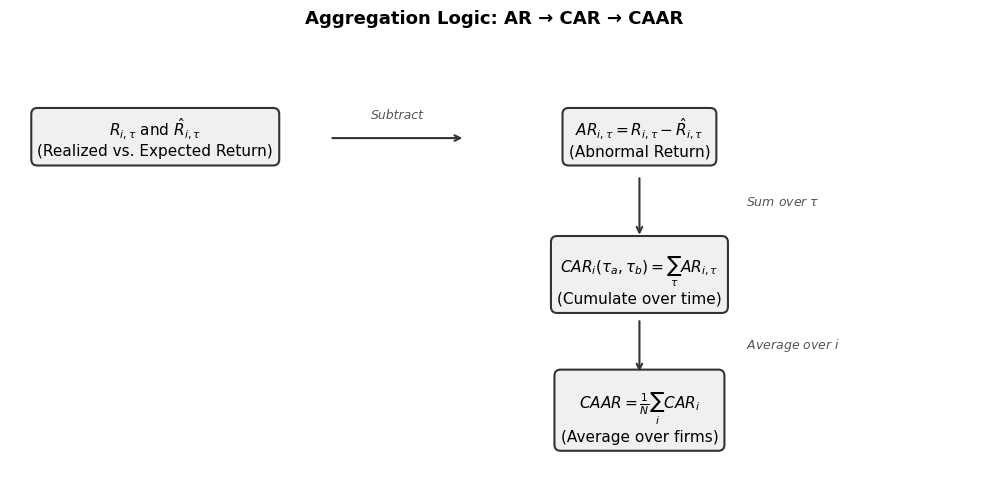

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

box_style = dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="#333333", linewidth=1.5)
arrow_props = dict(arrowstyle='->', color='#333333', linewidth=1.5)

# Boxes
boxes = [
    (1.5, 5.5, '$R_{i,\\tau}$ and $\\hat{R}_{i,\\tau}$\n(Realized vs. Expected Return)'),
    (6.5, 5.5, '$AR_{i,\\tau} = R_{i,\\tau} - \\hat{R}_{i,\\tau}$\n(Abnormal Return)'),
    (6.5, 3.2, '$CAR_i(\\tau_a, \\tau_b) = \\sum_{\\tau} AR_{i,\\tau}$\n(Cumulate over time)'),
    (6.5, 1.0, '$CAAR = \\frac{1}{N}\\sum_i CAR_i$\n(Average over firms)'),
]

for x, y, text in boxes:
    ax.text(x, y, text, ha='center', va='center', fontsize=11, bbox=box_style)

# Arrows
arrows = [
    ((3.3, 5.5), (4.7, 5.5)),
    ((6.5, 4.9), (6.5, 3.9)),
    ((6.5, 2.6), (6.5, 1.7)),
]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=arrow_props)

# Labels on arrows
ax.text(4.0, 5.8, 'Subtract', ha='center', fontsize=9, fontstyle='italic', color='#555555')
ax.text(7.6, 4.4, 'Sum over $\\tau$', ha='left', fontsize=9, fontstyle='italic', color='#555555')
ax.text(7.6, 2.1, 'Average over $i$', ha='left', fontsize=9, fontstyle='italic', color='#555555')

ax.set_title('Aggregation Logic: AR → CAR → CAAR', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Common Pitfalls in Event Study Design

Before turning to an empirical application, it is worth cataloguing the most frequent design errors. Most of the following are not exotic problems; they appear routinely in published work.

**Event date misidentification.** The event date must be the date on which the market *first* learned of the event, not the date on which the event occurred. For instance, an M&A deal may be publicly rumored on Monday but officially announced on Wednesday. If we use Wednesday as $\tau = 0$, we miss the actual information arrival and underestimate the event's impact. Press reports, SEC filings with timestamps, and newswire databases (Factiva, Bloomberg) help pin down the correct date.

**Overlapping event windows.** If two events affecting the same firm occur within each other's event windows, the abnormal returns conflate the effects of both. The standard solution is to drop observations with confounding events within the event window, though this introduces sample selection issues. An alternative, explored in Session 10, is to model multiple events jointly using intervention analysis.

**Look-ahead bias.** This arises when the sample is selected based on information that was not available at the event date. For example, studying "successful acquisitions" (defined by post-merger performance) conditions on the outcome and biases the measured announcement return. The sample should always be defined using information available at or before the event date.

**Estimation window contamination.** If the estimation window includes earlier events that shifted the firm's risk profile, the estimated parameters $\hat{\alpha}_i$ and $\hat{\beta}_i$ will be biased. This is why the buffer exists and why some studies exclude firms with confounding events in the estimation window.

**Thin trading and non-synchronous trading.** Stocks that trade infrequently exhibit spurious autocorrelation in returns and biased beta estimates. Scholes and Williams (1977) and Dimson (1979) propose corrections, and we will revisit this in Session 2.

## 7. Application: An Event Study of an Earnings Announcement

We now implement a complete event study from scratch. The example uses Apple's Q1 2024 earnings announcement (February 1, 2024) as the event. We estimate the market model over a 250-day estimation window, compute abnormal returns in a $[-5, +5]$ event window, and cumulate them.

This is deliberately kept simple to illustrate the mechanics. Sessions 2–5 will refine the benchmark model and the inference.

### 7.1 Data Collection

We retrieve daily adjusted closing prices for Apple (AAPL) and the S&P 500 index (^GSPC) from Yahoo Finance. From prices we compute log returns, which are additive over time and thus consistent with the CAR formula.

In [40]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Define event and tickers
event_date = pd.Timestamp('2024-02-01')
ticker = 'AAPL'
market_ticker = '^GSPC'

# Download data with sufficient history
# We need ~300 trading days before the event + post-event days
start_date = '2022-10-01'
end_date = '2024-03-01'

data_firm = yf.download(ticker, start=start_date, end=end_date, progress=False)
data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False)

# Flatten multi-level columns if needed
if isinstance(data_firm.columns, pd.MultiIndex):
    data_firm.columns = data_firm.columns.get_level_values(0)
if isinstance(data_market.columns, pd.MultiIndex):
    data_market.columns = data_market.columns.get_level_values(0)

# Compute log returns
prices = pd.DataFrame({
    'firm': data_firm['Close'],
    'market': data_market['Close']
}).dropna()

returns = np.log(prices / prices.shift(1)).dropna()
returns.index = returns.index.tz_localize(None)

print(f"Sample: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Total trading days: {len(returns)}")
print(f"Event date: {event_date.date()}")
returns.tail()

YF.download() has changed argument auto_adjust default to True
Sample: 2022-10-04 to 2024-02-29
Total trading days: 353
Event date: 2024-02-01


,firm,market
Date,,
2024-02-23,-0.010085,0.000348
2024-02-26,-0.007479,-0.003794
2024-02-27,0.008082,0.001705
2024-02-28,-0.006648,-0.001660
2024-02-29,-0.003700,0.005215


### 7.2 Defining the Windows

We set the estimation window to 250 trading days ending 11 days before the event (a 10-day buffer). The event window spans $[-5, +5]$. We locate the event date in the trading calendar and define each window in terms of integer offsets.

In [43]:
# Locate event date in the trading day index
trading_days = returns.index
event_idx = trading_days.get_indexer([event_date], method='ffill')[0]
print(f"Event date maps to index {event_idx}: {trading_days[event_idx].date()}")

# Window parameters
est_window_length = 250
buffer = 10
event_window = (-5, 5)  # relative to event date

# Index boundaries
event_start = event_idx + event_window[0]
event_end = event_idx + event_window[1]
est_end = event_start - buffer - 1
est_start = est_end - est_window_length + 1

print(f"\nEstimation window: [{trading_days[est_start].date()}, {trading_days[est_end].date()}]"
      f"  ({est_end - est_start + 1} days)")
print(f"Buffer:            [{trading_days[est_end + 1].date()}, {trading_days[event_start - 1].date()}]"
      f"  ({buffer} days)")
print(f"Event window:      [{trading_days[event_start].date()}, {trading_days[event_end].date()}]"
      f"  ({event_end - event_start + 1} days)")

# Slice the data
est_returns = returns.iloc[est_start:est_end + 1].copy()
evt_returns = returns.iloc[event_start:event_end + 1].copy()

Event date maps to index 333: 2024-02-01

Estimation window: [2023-01-11, 2024-01-09]  (250 days)
Buffer:            [2024-01-10, 2024-01-24]  (10 days)
Event window:      [2024-01-25, 2024-02-08]  (11 days)


### 7.3 Estimating the Market Model

We estimate the market model by OLS over the estimation window:

$$
R_{i,t} = \hat{\alpha}_i + \hat{\beta}_i R_{m,t} + \hat{\varepsilon}_{i,t}
$$

We report the regression output and check the residuals for obvious problems (autocorrelation, heteroskedasticity). A full diagnostic battery is the subject of Session 2.

In [46]:
import statsmodels.api as sm

# Prepare estimation window data
y_est = est_returns['firm'].values
X_est = sm.add_constant(est_returns['market'].values)

# OLS estimation
model = sm.OLS(y_est, X_est).fit()

alpha_hat = model.params[0]
beta_hat = model.params[1]
sigma_eps = np.sqrt(model.mse_resid)

print("Market Model Estimation Results")
print("=" * 45)
print(f"  alpha_hat  = {alpha_hat:.6f}")
print(f"  beta_hat   = {beta_hat:.4f}")
print(f"  sigma_eps  = {sigma_eps:.6f}")
print(f"  R-squared  = {model.rsquared:.4f}")
print(f"  Obs        = {model.nobs:.0f}")
print(f"\n  Durbin-Watson statistic: {sm.stats.stattools.durbin_watson(model.resid):.3f}")
print(f"  (Values near 2 indicate no serial correlation)")

Market Model Estimation Results
  alpha_hat  = 0.000554
  beta_hat   = 1.1101
  sigma_eps  = 0.008886
  R-squared  = 0.5093
  Obs        = 250

  Durbin-Watson statistic: 1.721
  (Values near 2 indicate no serial correlation)


### 7.4 Computing Abnormal Returns and CAR

With the estimated parameters in hand, we compute the abnormal return for each day in the event window:

$$
AR_{i,\tau} = R_{i,\tau} - \hat{\alpha}_i - \hat{\beta}_i R_{m,\tau}
$$

We then cumulate to obtain $CAR_i(-5, \tau)$ for each $\tau$ from $-5$ to $+5$.

In [48]:
# Compute expected returns in the event window
evt_market = evt_returns['market'].values
expected_returns = alpha_hat + beta_hat * evt_market

# Abnormal returns
ar = evt_returns['firm'].values - expected_returns

# Cumulative abnormal returns
car = np.cumsum(ar)

# Build results table
event_days = list(range(event_window[0], event_window[1] + 1))
results = pd.DataFrame({
    'Event Day (τ)': event_days,
    'Date': evt_returns.index.strftime('%Y-%m-%d').tolist(),
    'R_firm (%)': evt_returns['firm'].values * 100,
    'R_market (%)': evt_returns['market'].values * 100,
    'E[R] (%)': expected_returns * 100,
    'AR (%)': ar * 100,
    'CAR (%)': car * 100,
}).set_index('Event Day (τ)')

print("Abnormal Returns and CARs around the Earnings Announcement")
print("=" * 72)
print(results.round(4).to_string())

Abnormal Returns and CARs around the Earnings Announcement
                     Date  R_firm (%)  R_market (%)  E[R] (%)  AR (%)  CAR (%)
Event Day (τ)                                                                 
-5             2024-01-25     -0.1698        0.5247    0.6379 -0.8077  -0.8077
-4             2024-01-26     -0.9054       -0.0652   -0.0169 -0.8884  -1.6961
-3             2024-01-29     -0.3593        0.7528    0.8912 -1.2505  -2.9466
-2             2024-01-30     -1.9433       -0.0601   -0.0113 -1.9321  -4.8787
-1             2024-01-31     -1.9547       -1.6237   -1.7471 -0.2077  -5.0863
 0             2024-02-01      1.3252        1.2416    1.4338 -0.1086  -5.1949
 1             2024-02-02     -0.5420        1.0628    1.2353 -1.7773  -6.9722
 2             2024-02-05      0.9799       -0.3191   -0.2988  1.2787  -5.6935
 3             2024-02-06      0.8594        0.2308    0.3116  0.5478  -5.1457
 4             2024-02-07      0.0581        0.8208    0.9666 -0.9085  -

### 7.5 Visualizing the Results

Two plots complete the analysis: (1) daily abnormal returns as a bar chart, showing the timing and direction of the price reaction, and (2) the cumulative abnormal return path, showing the total impact and whether it reverses.

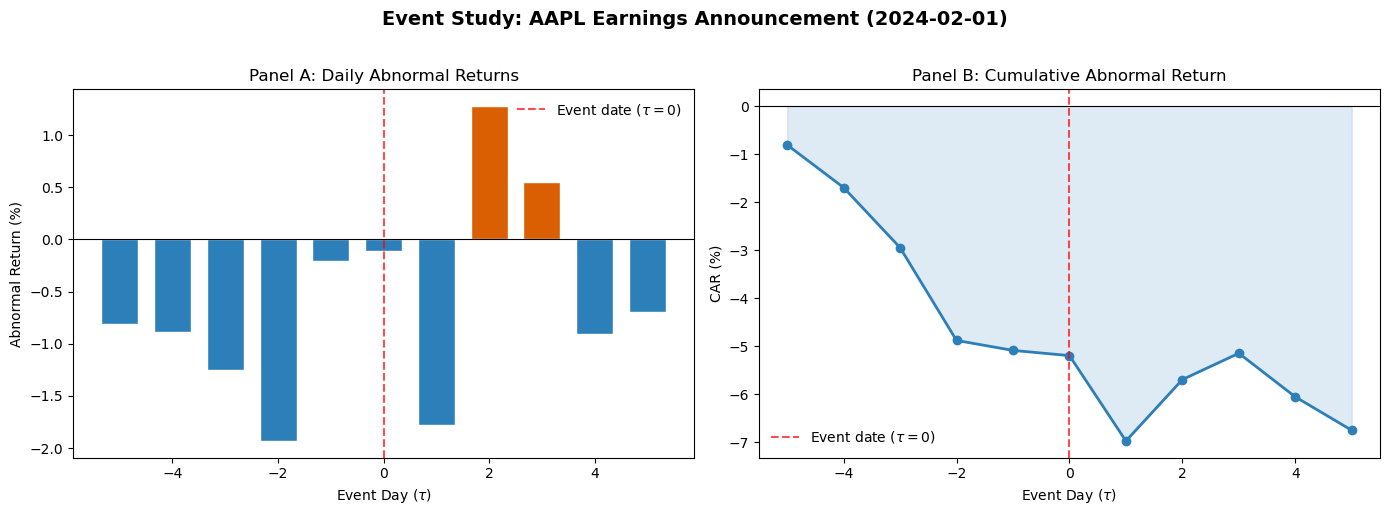

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: Daily ARs ---
colors = ['#d95f02' if v >= 0 else '#2c7fb8' for v in ar * 100]
axes[0].bar(event_days, ar * 100, color=colors, edgecolor='white', width=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.7, label='Event date ($\\tau=0$)')
axes[0].set_xlabel('Event Day ($\\tau$)')
axes[0].set_ylabel('Abnormal Return (%)')
axes[0].set_title('Panel A: Daily Abnormal Returns')
axes[0].legend(frameon=False)

# --- Panel B: CAR ---
axes[1].plot(event_days, car * 100, 'o-', color='#2c7fb8', linewidth=2, markersize=6)
axes[1].fill_between(event_days, 0, car * 100, alpha=0.15, color='#2c7fb8')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.7, label='Event date ($\\tau=0$)')
axes[1].set_xlabel('Event Day ($\\tau$)')
axes[1].set_ylabel('CAR (%)')
axes[1].set_title('Panel B: Cumulative Abnormal Return')
axes[1].legend(frameon=False)

fig.suptitle(f'Event Study: {ticker} Earnings Announcement ({event_date.date()})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.6 A Preliminary Significance Test

Is the observed CAR statistically significant? We defer formal hypothesis testing to Sessions 4 and 5, but a simple t-test illustrates the logic. Under the null, the CAR over an event window of length $T_w$ days has variance approximately $T_w \cdot \sigma^2_{\varepsilon}$. The test statistic is:

$$
t = \frac{CAR_i(\tau_a, \tau_b)}{\sqrt{T_w \cdot \hat{\sigma}^2_{\varepsilon}}}
$$

This test is valid under the assumption of i.i.d. normally distributed abnormal returns with no event-induced variance change. Session 4 relaxes these assumptions systematically.

In [52]:
from scipy import stats

T_w = event_window[1] - event_window[0] + 1
car_total = car[-1]
var_car = T_w * sigma_eps**2
se_car = np.sqrt(var_car)
t_stat = car_total / se_car
p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))

print("Preliminary t-test for CAR(-5, +5)")
print("=" * 45)
print(f"  CAR(-5, +5)    = {car_total * 100:.4f}%")
print(f"  SE(CAR)        = {se_car * 100:.4f}%")
print(f"  t-statistic    = {t_stat:.4f}")
print(f"  p-value (2-s)  = {p_value:.4f}")
print(f"\n  Conclusion at 5% level: {'Reject H0 (significant)' if p_value < 0.05 else 'Fail to reject H0'}")

Preliminary t-test for CAR(-5, +5)
  CAR(-5, +5)    = -6.7501%
  SE(CAR)        = 2.9470%
  t-statistic    = -2.2905
  p-value (2-s)  = 0.0220

  Conclusion at 5% level: Reject H0 (significant)


## 8. Scope of Applications

The event study template developed above applies, with minor modifications, to a wide range of settings in finance and economics. Three canonical applications illustrate the breadth:

**Earnings announcements.** Ball and Brown (1968) showed that stock prices respond to earnings surprises, and that the direction of the price adjustment is predictable from the sign of the earnings surprise. This was among the earliest evidence consistent with semi-strong efficiency. The post-earnings announcement drift (PEAD) documented by Bernard and Thomas (1989) remains one of the most robust anomalies.

**Mergers and acquisitions.** Event studies of M&A announcements consistently find that target shareholders earn large positive abnormal returns (on the order of 15–30%), while acquirer shareholders earn returns close to zero or slightly negative (Andrade, Mitchell, and Stafford, 2001). The cross-sectional variation in acquirer returns is the subject of Session 6.

**Central bank decisions.** Monetary policy surprises, measured as the unexpected component of interest rate changes, generate significant abnormal returns in equity, bond, and foreign exchange markets (Bernanke and Kuttner, 2005). Intraday event studies using tick data (Session 10) provide the sharpest identification because the announcement time is known to the minute.

Each of these settings raises specific methodological challenges, such as the definition of the "surprise" component, the treatment of anticipation effects, and the choice of benchmark model. The subsequent sessions address these challenges one by one.

## 9. Summary and Preview of Session 2

This session established the conceptual and mathematical foundations of the event study methodology. The key ideas are:

The abnormal return $AR_{i,\tau} = R_{i,\tau} - \hat{R}_{i,\tau}$ measures the component of the return attributable to the event. This requires a model for normal returns, which we estimated here using the market model. The abnormal return aggregates across time (into CARs) and across firms (into CAARs), and a test statistic can be constructed under the null of no event effect.

We also identified five common pitfalls: event date misidentification, overlapping event windows, look-ahead bias, estimation window contamination, and thin trading effects. Avoiding these errors is as important as choosing the right statistical test.

Session 2 turns to the question that most directly affects the quality of inference: the choice of normal return model. We will compare the constant mean model, the market model, and multi-factor models (Fama-French 3-factor, Carhart 4-factor, Fama-French 5-factor), estimate them on the same data, and evaluate how much the model choice matters for measured abnormal returns.

**Additional references:**

- Andrade, G., Mitchell, M. and Stafford, E. (2001). New Evidence and Perspectives on Mergers. *Journal of Economic Perspectives*, 15(2), 103–120.
- Bernanke, B.S. and Kuttner, K.N. (2005). What Explains the Stock Market's Reaction to Federal Reserve Policy? *Journal of Finance*, 60(3), 1221–1257.
- Bernard, V.L. and Thomas, J.K. (1989). Post-Earnings-Announcement Drift: Delayed Price Response or Risk Premium? *Journal of Accounting Research*, 27, 1–36.
- Brown, S.J. and Warner, J.B. (1980). Measuring Security Price Performance. *Journal of Financial Economics*, 8(3), 205–258.
- Brown, S.J. and Warner, J.B. (1985). Using Daily Stock Returns. *Journal of Financial Economics*, 14(1), 3–31.
- Dimson, E. (1979). Risk Measurement When Shares Are Subject to Infrequent Trading. *Journal of Financial Economics*, 7(2), 197–226.
- Peterson, P.P. (1989). Event Studies: A Review of Issues and Methodology. *Quarterly Journal of Business and Economics*, 28(3), 36–66.
- Scholes, M. and Williams, J. (1977). Estimating Betas from Nonsynchronous Data. *Journal of Financial Economics*, 5(3), 309–327.